In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/para.txt'

with open(file_path, 'r', encoding='utf-8') as f:
    raw_text = f.read()

print("Raw text length:", len(raw_text))

Raw text length: 2206319


You can download the `cleaned_corpus.txt` file from the Colab file browser. Look for the folder icon on the left sidebar, navigate to `/content/`, and you will find the file there.

In [5]:
import re

text = raw_text.lower()

# remove URLs
text = re.sub(r'http\S+', '', text)

# remove numbers
text = re.sub(r'\d+', '', text)

# remove punctuation
text = re.sub(r'[^a-z\s]', ' ', text)

# remove extra spaces
text = re.sub(r'\s+', ' ', text)

sentences = text.split(".")

clean_sentences = []

for sent in sentences:
    words = sent.strip().split()

    # keep short words like ug, pg, phd
    words = [w for w in words if len(w) > 1]

    if len(words) > 1:
        clean_sentences.append(words)

print(clean_sentences[:5])


print("Cleaned text length:", len(text))

[['teacher', 'teaches', 'students', 'student', 'learns', 'from', 'teacher', 'teachers', 'teach', 'students', 'students', 'learn', 'from', 'teachers', 'professor', 'guides', 'research', 'research', 'is', 'guided', 'by', 'professor', 'professors', 'guide', 'research', 'students', 'research', 'students', 'work', 'under', 'professors', 'btech', 'student', 'studies', 'engineering', 'phd', 'student', 'conducts', 'research', 'phd', 'students', 'are', 'researchers', 'btech', 'students', 'are', 'learners', 'teacher', 'teaches', 'students', 'student', 'learns', 'from', 'teacher', 'teachers', 'teach', 'students', 'students', 'learn', 'from', 'teachers', 'professor', 'guides', 'research', 'research', 'is', 'guided', 'by', 'professor', 'professors', 'guide', 'research', 'students', 'research', 'students', 'work', 'under', 'professors', 'btech', 'student', 'studies', 'engineering', 'phd', 'student', 'conducts', 'research', 'phd', 'students', 'are', 'researchers', 'btech', 'students', 'are', 'learner

In [23]:
tokens = text.split()

In [24]:
stopwords = set([
    "the","is","in","and","to","of","for","on","with","as","by","at",
    "an","be","this","that","from","are","was","were","or","it","we",
    "has","have","had","but","not","which","their","its","also"
])

tokens = [w for w in tokens if w not in stopwords]

tokens = [w for w in tokens if len(w) > 1]

In [25]:
noise_words = set([
    "indian","institute","technology","jodhpur","about","page",
    "redirecttologinpage","home","login","faculty","department",
    "iit","iitj","menu","main","program","programs","details","apply","online",
    "eligibility","fee","contact","important","dates",
    "assistantship","staff","member","campus","faq","faqs",
    "vision","mission","imprint","alumni","relation","relations",
    "tech","park",
    "conference","conferences",
    "visitor","visitors",
    "member","members",
    "recruitment",
    "school","aide",
    "board","governors",
    "liberal","arts",
    "council","management","office","committee","events","latest","facilities",
    "program","details","apply","online","contact","important"
])

tokens = [w for w in tokens if w not in noise_words]

weak_words = set([
    "established","committed","benefit","action","thought",
    "three","functions","acres","sprawling","permanent",
    "driving","creative","relevance"
])

tokens = [w for w in tokens if w not in weak_words]

In [76]:
# convert sentences → text
clean_text = "\n".join([" ".join(sent) for sent in clean_sentences])

# save to file
output_path = "/corpus.txt"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(clean_text)

print("File saved at:", output_path)

File saved at: /corpus.txt


In [26]:
from collections import Counter

freq = Counter(tokens)


In [27]:
from collections import Counter

def build_vocab(tokens, min_freq=3):
    freq = Counter(tokens)
    vocab = [w for w in freq if freq[w] >= min_freq]

    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}

    return vocab, word2idx, idx2word

vocab, word2idx, idx2word = build_vocab(tokens)
vocab_size = len(vocab)

print("Vocab size:", vocab_size)

Vocab size: 3715


In [28]:
vocab = set(tokens)

print("Clean Tokens:", len(tokens))
print("Vocabulary Size:", len(vocab))

print("Sample:", tokens[:30])

Clean Tokens: 165547
Vocabulary Size: 7481
Sample: ['teacher', 'teaches', 'students', 'student', 'learns', 'teacher', 'teachers', 'teach', 'students', 'students', 'learn', 'teachers', 'professor', 'guides', 'research', 'research', 'guided', 'professor', 'professors', 'guide', 'research', 'students', 'research', 'students', 'work', 'under', 'professors', 'btech', 'student', 'studies']


In [29]:
import numpy as np
import random
from collections import Counter

In [30]:
# tokens already created from preprocessing

# build vocab
vocab = list(set(tokens))
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
V = len(vocab)

print("Vocab size:", V)

Vocab size: 7481


In [31]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [16]:
def generate_cbow(tokens, window):
    data = []
    for i in range(window, len(tokens)-window):
        context = []
        for j in range(-window, window+1):
            if j != 0 and tokens[i+j] in word2idx:
                context.append(word2idx[tokens[i+j]])

        if tokens[i] in word2idx and len(context)>0:
            data.append((context, word2idx[tokens[i]]))
    return data

In [17]:
def generate_skipgram(tokens, window):
    data = []
    for i in range(window, len(tokens)-window):
        if tokens[i] not in word2idx:
            continue

        target = word2idx[tokens[i]]

        for j in range(-window, window+1):
            if j != 0 and tokens[i+j] in word2idx:
                context = word2idx[tokens[i+j]]
                data.append((target, context))
    return data

In [18]:
def train_cbow(data, embed_size, epochs=3, lr=0.05):

    W1 = np.random.randn(V, embed_size) * 0.01
    W2 = np.random.randn(embed_size, V) * 0.01

    for epoch in range(epochs):
        loss = 0

        for context, target in data[:20000]:

            h = np.mean(W1[context], axis=0)
            u = np.dot(h, W2)
            y = softmax(u)

            loss -= np.log(y[target] + 1e-9)

            e = y
            e[target] -= 1

            dW2 = np.outer(h, e)
            dW1 = np.dot(W2, e) / len(context)

            for c in context:
                W1[c] -= lr * dW1

            W2 -= lr * dW2

        print(f"CBOW Epoch {epoch+1}, Loss: {round(loss,2)}")

    return W1

In [19]:
def train_skipgram(data, embed_size, neg_samples=2, epochs=2, lr=0.05):

    W1 = np.random.randn(V, embed_size) * 0.01
    W2 = np.random.randn(embed_size, V) * 0.01

    for epoch in range(epochs):
        loss = 0

        for target, context in data[:20000]:

            # positive
            score = sigmoid(np.dot(W1[target], W2[:, context]))
            loss -= np.log(score + 1e-9)

            grad = score - 1
            W1[target] -= lr * grad * W2[:, context]
            W2[:, context] -= lr * grad * W1[target]

            # negative samples
            for _ in range(neg_samples):
                neg = random.randint(0, V-1)

                score_neg = sigmoid(np.dot(W1[target], W2[:, neg]))
                loss -= np.log(1 - score_neg + 1e-9)

                grad_neg = score_neg
                W1[target] -= lr * grad_neg * W2[:, neg]
                W2[:, neg] -= lr * grad_neg * W1[target]

        print(f"SkipGram Epoch {epoch+1}, Loss: {round(loss,2)}")

    return W1

In [75]:
embed_sizes = [50, 100,200,300]
windows = [2, 4]
negatives = [2, 5]

results = []

for emb in embed_sizes:
    for win in windows:

        print(f"\n===== CBOW (emb={emb}, window={win}) =====")
        cbow_data = generate_cbow(tokens[:5000], win)
        W_cbow = train_cbow(cbow_data, emb)

        results.append(("CBOW", emb, win, "-", "done"))

        print(f"\n===== SkipGram (emb={emb}, window={win}) =====")
        sg_data = generate_skipgram(tokens, win)

        for neg in negatives:
            print(f"\nNeg samples = {neg}")
            W_sg = train_skipgram(sg_data, emb, neg)

            results.append(("SkipGram", emb, win, neg, "done"))


===== CBOW (emb=50, window=2) =====
CBOW Epoch 1, Loss: 44555.33
CBOW Epoch 2, Loss: 43129.12
CBOW Epoch 3, Loss: 37468.16

===== SkipGram (emb=50, window=2) =====

Neg samples = 2
SkipGram Epoch 1, Loss: 40761.53
SkipGram Epoch 2, Loss: 35751.68

Neg samples = 5
SkipGram Epoch 1, Loss: 81574.71
SkipGram Epoch 2, Loss: 58460.26

===== CBOW (emb=50, window=4) =====
CBOW Epoch 1, Loss: 44518.8
CBOW Epoch 2, Loss: 42560.97
CBOW Epoch 3, Loss: 36807.95

===== SkipGram (emb=50, window=4) =====

Neg samples = 2
SkipGram Epoch 1, Loss: 34628.31
SkipGram Epoch 2, Loss: 21588.54

Neg samples = 5
SkipGram Epoch 1, Loss: 65535.32
SkipGram Epoch 2, Loss: 25208.36

===== CBOW (emb=100, window=2) =====
CBOW Epoch 1, Loss: 44547.86
CBOW Epoch 2, Loss: 42637.84
CBOW Epoch 3, Loss: 37032.98

===== SkipGram (emb=100, window=2) =====

Neg samples = 2
SkipGram Epoch 1, Loss: 40565.24
SkipGram Epoch 2, Loss: 35396.98

Neg samples = 5
SkipGram Epoch 1, Loss: 80805.31
SkipGram Epoch 2, Loss: 55928.21

=====

In [77]:
print("\nFINAL RESULTS\n")

print("Model | Embedding | Window | Neg Samples")
for r in results:
    print(r)


FINAL RESULTS

Model | Embedding | Window | Neg Samples
('CBOW', 50, 2, '-', 'done')
('SkipGram', 50, 2, 2, 'done')
('SkipGram', 50, 2, 5, 'done')
('CBOW', 50, 4, '-', 'done')
('SkipGram', 50, 4, 2, 'done')
('SkipGram', 50, 4, 5, 'done')
('CBOW', 100, 2, '-', 'done')
('SkipGram', 100, 2, 2, 'done')
('SkipGram', 100, 2, 5, 'done')
('CBOW', 100, 4, '-', 'done')
('SkipGram', 100, 4, 2, 'done')
('SkipGram', 100, 4, 5, 'done')
('CBOW', 200, 2, '-', 'done')
('SkipGram', 200, 2, 2, 'done')
('SkipGram', 200, 2, 5, 'done')
('CBOW', 200, 4, '-', 'done')
('SkipGram', 200, 4, 2, 'done')
('SkipGram', 200, 4, 5, 'done')
('CBOW', 300, 2, '-', 'done')
('SkipGram', 300, 2, 2, 'done')
('SkipGram', 300, 2, 5, 'done')
('CBOW', 300, 4, '-', 'done')
('SkipGram', 300, 4, 2, 'done')
('SkipGram', 300, 4, 5, 'done')


In [78]:
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

In [79]:
embeddings = W_cbow   # OR W_sg
embeddings1 = cbow_data   # OR W_sg

In [80]:
def get_neighbors(word, k=5):
    if word not in word2idx:
        print(word, "not in vocab")
        return

    vec = embeddings[word2idx[word]]

    sims = []
    for w in vocab:
        if w == word:
            continue

        sim = cosine(vec, embeddings[word2idx[w]])
        sims.append((w, sim))

    sims.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop {k} neighbors for '{word}':")
    for w, s in sims[:k]:
        print(w, round(s, 4))



In [81]:
def get_neighbors1(word, k=5):
    if word not in word2idx:
        print(word, "not in vocab")
        return

    vec = embeddings1[word2idx[word]]

    sims = []
    for w in vocab:
        if w == word:
            continue

        sim = cosine(vec, embeddings1[word2idx[w]])
        sims.append((w, sim))

    sims.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop {k} neighbors for '{word}':")
    for w, s in sims[:k]:
        print(w, round(s, 4))

In [82]:
def get_neighbors(word, W, k=5):
    if word not in word2idx:
        print(word, "not in vocab")
        return

    vec = W[word2idx[word]]

    sims = []
    for w in vocab:
        if w == word:
            continue

        sim = cosine(vec, W[word2idx[w]])
        sims.append((w, sim))

    sims.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop {k} neighbors for '{word}':")
    for w, s in sims[:k]:
        print(w, round(s, 4))

In [83]:
get_neighbors("student", W_cbow)
get_neighbors("research", W_cbow)


Top 5 neighbors for 'student':
learns 0.9802
studies 0.9675
teacher 0.9667
university 0.9661
professor 0.9637

Top 5 neighbors for 'research':
professor 0.9928
under 0.9885
phd 0.9877
guided 0.9819
professors 0.9758


In [84]:
def analogy(a, b, c, W, k=5):
    if a not in word2idx or b not in word2idx or c not in word2idx:
        print("missing word")
        return

    vec = W[word2idx[b]] - W[word2idx[a]] + W[word2idx[c]]

    sims = []
    for w in vocab:
        if w in [a, b, c]:
            continue

        sim = cosine(vec, W[word2idx[w]])
        sims.append((w, sim))

    sims.sort(key=lambda x: x[1], reverse=True)

    print(f"{a}:{b} :: {c}:?")
    for w, s in sims[:k]:
        print(w, round(s,4))

In [87]:
def evaluate_model(name, W):
    print("\n==============================")
    print(f"MODEL: {name}")
    print("==============================")

    # Neighbors
    print("\n--- Nearest Neighbors ---")
    for word in ["student", "research", "phd", "exam"]:
        print(f"\nWord: {word}")
        get_neighbors(word, W)

    #  Analogies
    print("\n--- Analogies ---")

    print("\nUG : BTech :: PG : ?")
    analogy("ug", "btech", "pg", W)

    print("\nstudent : teacher :: research : ?")
    analogy("student", "teacher", "research", W)

    print("\nbtech : student :: phd : ?")
    analogy("btech", "student", "phd", W)

In [86]:
# Example for CBOW
evaluate_model("CBOW (emb=300, win=2)", W_cbow)

# Example for SkipGram
evaluate_model("SkipGram (emb=300, win=2, neg=5)", W_sg)


MODEL: CBOW (emb=300, win=2)

--- Nearest Neighbors ---

Word: student

Top 5 neighbors for 'student':
learns 0.9802
studies 0.9675
teacher 0.9667
university 0.9661
professor 0.9637

Word: research

Top 5 neighbors for 'research':
professor 0.9928
under 0.9885
phd 0.9877
guided 0.9819
professors 0.9758

Word: phd

Top 5 neighbors for 'phd':
research 0.9877
professor 0.9872
under 0.9796
professors 0.9781
papers 0.9756

Word: exam

Top 5 neighbors for 'exam':
exams 0.8937
write 0.8922
teachers 0.8864
questions 0.8862
knowledge 0.8858

--- Analogies ---

UG : BTech :: PG : ?
ug:btech :: pg:?
mtech 0.987
courses 0.9856
degree 0.9779
study 0.9774
concepts 0.977

student : teacher :: research : ?
student:teacher :: research:?
phd 0.9306
professor 0.9113
under 0.9101
papers 0.9097
academic 0.9025

btech : student :: phd : ?
btech:student :: phd:?
professor 0.9451
guided 0.9384
guides 0.9331
works 0.933
research 0.9252

MODEL: SkipGram (emb=300, win=2, neg=5)

--- Nearest Neighbors ---

Word:

In [88]:
import numpy as np

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


def analogy(a, b, c):
    if a not in word2idx or b not in word2idx or c not in word2idx:
        print("missing word")
        return

    vec = embeddings[word2idx[b]] - embeddings[word2idx[a]] + embeddings[word2idx[c]]

    sims = []

    for w in vocab:
        if w in [a, b, c]:
            continue

        # filter weak/generic words
        if w in ["life", "more", "related", "very", "also", "such"]:
            continue

        sim = cosine_sim(vec, embeddings[word2idx[w]])
        sims.append((w, sim))

    sims.sort(key=lambda x: x[1], reverse=True)

    print(f"\n{a}:{b} :: {c}:?")
    for w, s in sims[:5]:
        print(w, round(s, 4))

In [89]:
analogy("ug", "btech", "pg")
analogy("student", "teacher", "research")
analogy("btech", "student", "phd")


ug:btech :: pg:?
mtech 0.987
courses 0.9856
degree 0.9779
study 0.9774
concepts 0.977

student:teacher :: research:?
phd 0.9306
professor 0.9113
under 0.9101
papers 0.9097
academic 0.9025

btech:student :: phd:?
professor 0.9451
guided 0.9384
guides 0.9331
works 0.933
research 0.9252


In [ ]:
!pip install wordcloud

In [91]:
from collections import Counter

# 🔹 Total documents (sentences)
num_docs = len(clean_sentences)

# 🔹 Total tokens
num_tokens = len(tokens)

# 🔹 Vocabulary size
vocab = set(tokens)
vocab_size = len(vocab)

print("Total Documents:", num_docs)
print("Total Tokens:", num_tokens)
print("Vocabulary Size:", vocab_size)

# 🔹 Top frequent words
freq = Counter(tokens)
print("\nTop 10 Frequent Words:")
for word, count in freq.most_common(10):
    print(word, count)

Total Documents: 1
Total Tokens: 165547
Vocabulary Size: 7481

Top 10 Frequent Words:
engineering 3145
research 2505
students 2319
mtech 1257
india 1228
academic 1046
infrastructure 1025
national 977
phd 949
director 929


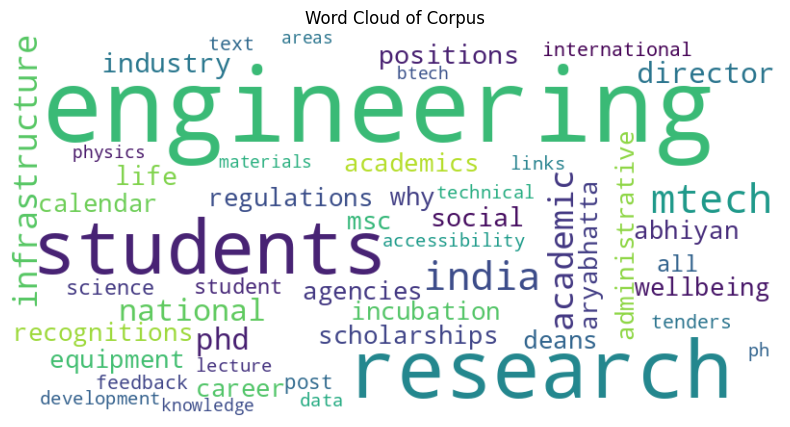

In [92]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

freq = Counter(tokens)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=50,        # 🔥 important
    relative_scaling=1   # 🔥 makes size proportional
).generate_from_frequencies(freq)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Corpus")
plt.show()

In [93]:
def score_model(W):
    def sim(a, b):
        return cosine(W[word2idx[a]], W[word2idx[b]])

    score = 0

    pairs = [
        ("student","teacher"),
        ("research","phd"),
        ("research","professor"),
        ("btech","student")
    ]

    for a, b in pairs:
        if a in word2idx and b in word2idx:
            score += sim(a, b)

    return score / len(pairs)

In [94]:
score = score_model(W_cbow)

results.append({
    "Model": "CBOW",
    "Emb": emb,
    "Window": win,
    "Neg": 0,
    "Score": score
})

In [95]:
score = score_model(W_sg)

results.append({
    "Model": "SkipGram",
    "Emb": emb,
    "Window": win,
    "Neg": neg,
    "Score": score
})

In [96]:
import pandas as pd

df = pd.DataFrame(results)

print(df)

           0    1       2    3      4
0       CBOW   50       2    -   done
1   SkipGram   50       2    2   done
2   SkipGram   50       2    5   done
3       CBOW   50       4    -   done
4   SkipGram   50       4    2   done
5   SkipGram   50       4    5   done
6       CBOW  100       2    -   done
7   SkipGram  100       2    2   done
8   SkipGram  100       2    5   done
9       CBOW  100       4    -   done
10  SkipGram  100       4    2   done
11  SkipGram  100       4    5   done
12      CBOW  200       2    -   done
13  SkipGram  200       2    2   done
14  SkipGram  200       2    5   done
15      CBOW  200       4    -   done
16  SkipGram  200       4    2   done
17  SkipGram  200       4    5   done
18      CBOW  300       2    -   done
19  SkipGram  300       2    2   done
20  SkipGram  300       2    5   done
21      CBOW  300       4    -   done
22  SkipGram  300       4    2   done
23  SkipGram  300       4    5   done
24     Model  Emb  Window  Neg  Score
25     Model

In [97]:
import pandas as pd

df = pd.DataFrame(results)

print(df)

           0    1       2    3      4
0       CBOW   50       2    -   done
1   SkipGram   50       2    2   done
2   SkipGram   50       2    5   done
3       CBOW   50       4    -   done
4   SkipGram   50       4    2   done
5   SkipGram   50       4    5   done
6       CBOW  100       2    -   done
7   SkipGram  100       2    2   done
8   SkipGram  100       2    5   done
9       CBOW  100       4    -   done
10  SkipGram  100       4    2   done
11  SkipGram  100       4    5   done
12      CBOW  200       2    -   done
13  SkipGram  200       2    2   done
14  SkipGram  200       2    5   done
15      CBOW  200       4    -   done
16  SkipGram  200       4    2   done
17  SkipGram  200       4    5   done
18      CBOW  300       2    -   done
19  SkipGram  300       2    2   done
20  SkipGram  300       2    5   done
21      CBOW  300       4    -   done
22  SkipGram  300       4    2   done
23  SkipGram  300       4    5   done
24     Model  Emb  Window  Neg  Score
25     Model

In [62]:
results = []

In [98]:
results = []

for emb in embed_sizes:
    for win in windows:

        print(f"\n===== CBOW (emb={emb}, window={win}) =====")
        cbow_data = generate_cbow(tokens[:5000], win)
        W_cbow = train_cbow(cbow_data, emb)

        score = score_model(W_cbow)

        results.append({
            "Model": "CBOW",
            "Emb": emb,
            "Window": win,
            "Neg": 0,
            "Score": score
        })

        print(f"\n===== SkipGram (emb={emb}, window={win}) =====")
        sg_data = generate_skipgram(tokens[:5000], win)

        for neg in negatives:
            print(f"\nNeg samples = {neg}")
            W_sg = train_skipgram(sg_data, emb, neg)

            score = score_model(W_sg)

            results.append({
                "Model": "SkipGram",
                "Emb": emb,
                "Window": win,
                "Neg": neg,
                "Score": score
            })


===== CBOW (emb=50, window=2) =====
CBOW Epoch 1, Loss: 44557.25
CBOW Epoch 2, Loss: 43411.25


KeyboardInterrupt: 

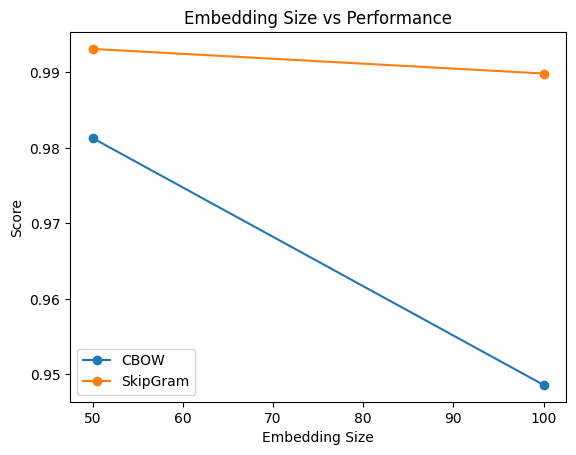

In [64]:
import matplotlib.pyplot as plt

cbow_emb = {}
sg_emb = {}

for r in results:
    if "Score" not in r:
        continue   # 🔥 skip bad entries

    if r["Window"] == 2:   # fix window for fair comparison
        if r["Model"] == "CBOW":
            cbow_emb[r["Emb"]] = r["Score"]
        elif r["Model"] == "SkipGram" and r["Neg"] == 2:
            sg_emb[r["Emb"]] = r["Score"]

plt.figure()
plt.plot(list(cbow_emb.keys()), list(cbow_emb.values()), marker='o', label="CBOW")
plt.plot(list(sg_emb.keys()), list(sg_emb.values()), marker='o', label="SkipGram")

plt.xlabel("Embedding Size")
plt.ylabel("Score")
plt.title("Embedding Size vs Performance")
plt.legend()
plt.show()

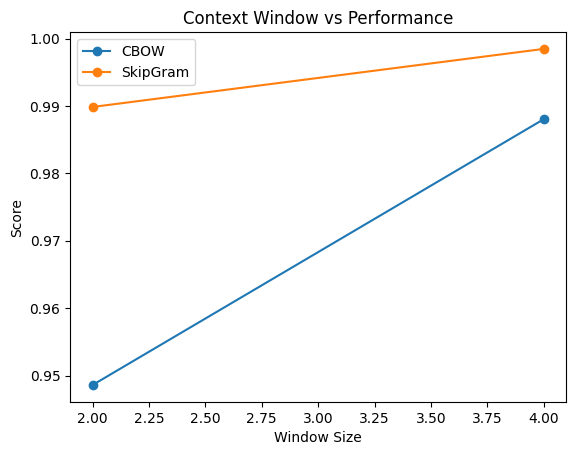

In [65]:
cbow_win = {}
sg_win = {}

for r in results:
    if "Score" not in r:
        continue

    if r["Emb"] == 100:   # fix embedding
        if r["Model"] == "CBOW":
            cbow_win[r["Window"]] = r["Score"]
        elif r["Model"] == "SkipGram" and r["Neg"] == 2:
            sg_win[r["Window"]] = r["Score"]

plt.figure()
plt.plot(list(cbow_win.keys()), list(cbow_win.values()), marker='o', label="CBOW")
plt.plot(list(sg_win.keys()), list(sg_win.values()), marker='o', label="SkipGram")

plt.xlabel("Window Size")
plt.ylabel("Score")
plt.title("Context Window vs Performance")
plt.legend()
plt.show()

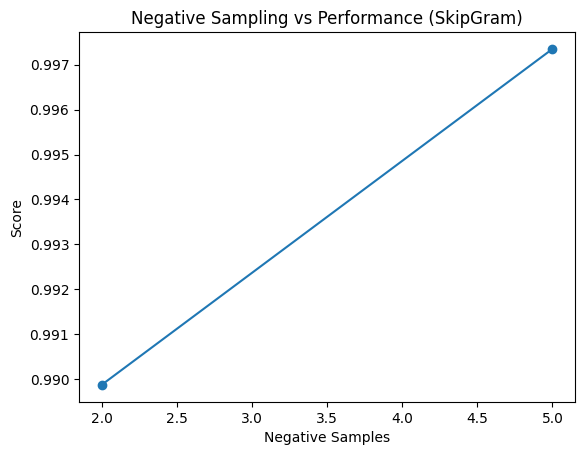

In [66]:
neg_scores = {}

for r in results:
    if "Score" not in r:
        continue

    if r["Model"] == "SkipGram" and r["Emb"] == 100 and r["Window"] == 2:
        neg_scores[r["Neg"]] = r["Score"]

plt.figure()
plt.plot(list(neg_scores.keys()), list(neg_scores.values()), marker='o')

plt.xlabel("Negative Samples")
plt.ylabel("Score")
plt.title("Negative Sampling vs Performance (SkipGram)")
plt.show()

In [68]:
words = [
    "engineering","research","students","mtech",
    "india","academic","infrastructure",
    "national","phd","director"
]

In [69]:
vectors = []
labels = []

for w in words:
    if w in word2idx:
        vectors.append(W_cbow[word2idx[w]])
        labels.append(w)

vectors = np.array(vectors)

In [70]:
vectors_sg = []
labels_sg = []

for w in words:
    if w in word2idx:
        vectors_sg.append(W_sg[word2idx[w]])
        labels_sg.append(w)

vectors_sg = np.array(vectors_sg)

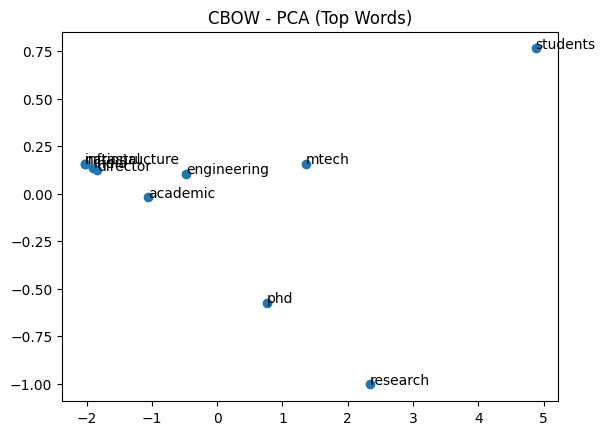

In [71]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

vec_2d = PCA(n_components=2).fit_transform(vectors)

plt.figure()
plt.scatter(vec_2d[:,0], vec_2d[:,1])

for i, word in enumerate(labels):
    plt.annotate(word, (vec_2d[i,0], vec_2d[i,1]))

plt.title("CBOW - PCA (Top Words)")
plt.show()

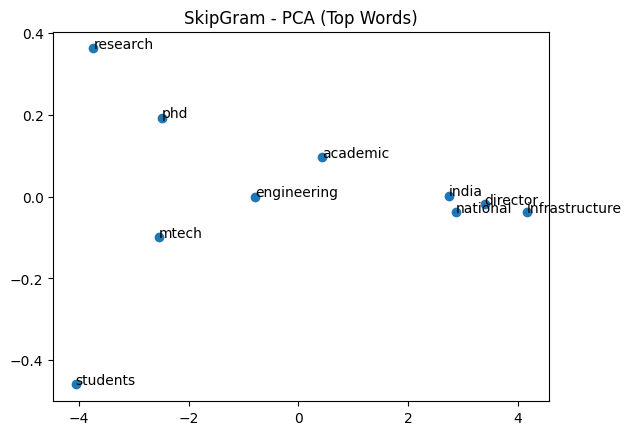

In [72]:
vec_2d_sg = PCA(n_components=2).fit_transform(vectors_sg)

plt.figure()
plt.scatter(vec_2d_sg[:,0], vec_2d_sg[:,1])

for i, word in enumerate(labels_sg):
    plt.annotate(word, (vec_2d_sg[i,0], vec_2d_sg[i,1]))

plt.title("SkipGram - PCA (Top Words)")
plt.show()

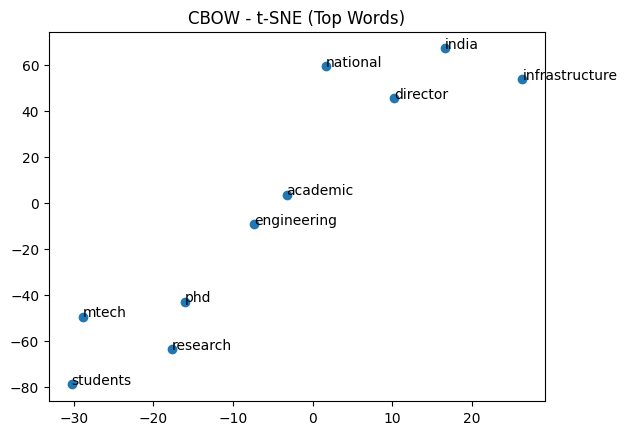

In [73]:
from sklearn.manifold import TSNE

vec_2d = TSNE(n_components=2, random_state=42, perplexity=3).fit_transform(vectors)

plt.figure()
plt.scatter(vec_2d[:,0], vec_2d[:,1])

for i, word in enumerate(labels):
    plt.annotate(word, (vec_2d[i,0], vec_2d[i,1]))

plt.title("CBOW - t-SNE (Top Words)")
plt.show()

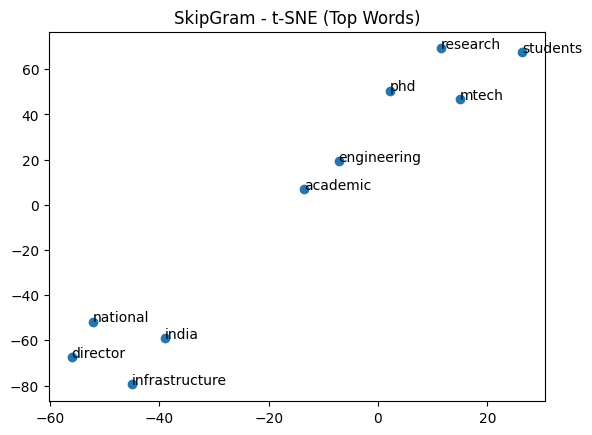

In [74]:
vec_2d_sg = TSNE(n_components=2, random_state=42, perplexity=3).fit_transform(vectors_sg)

plt.figure()
plt.scatter(vec_2d_sg[:,0], vec_2d_sg[:,1])

for i, word in enumerate(labels_sg):
    plt.annotate(word, (vec_2d_sg[i,0], vec_2d_sg[i,1]))

plt.title("SkipGram - t-SNE (Top Words)")
plt.show()